In [1]:
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.hardware.cameras.simulated import SimulatedCamera
from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography.toolbox.phase import zernike_sum
from slmsuite.holography.toolbox.phase import zernike

from slmsuite.holography import toolbox

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


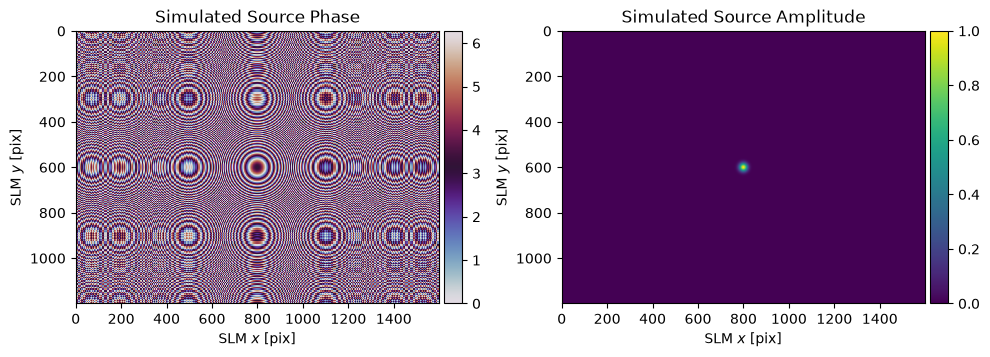

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: 'camera' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


{'M': array([[9250.,    0.],
        [   0., 9250.]]),
 'b': array([[512.],
        [512.]]),
 'a': array([[0],
        [0]]),
 '__version__': '0.4.1',
 '__time__': '2026-08-21 15:16:58.162602',
 '__timestamp__': 1787321818.162602,
 '__meta__': {'__class__': '<slmsuite.hardware.cameraslms.FourierSLM object at 0x00000199D125E600>',
  'name': 'camera-SLM',
  'cam': {'__class__': '<slmsuite.hardware.cameras.simulated.SimulatedCamera object at 0x00000199D11E0320>',
   'name': 'camera',
   'shape': (1024, 1024),
   'bitdepth': 8,
   'bitresolution': 256,
   'pitch_um': array([4., 4.]),
   'exposure_s': 1,
   'exposure_bounds_s': None,
   'averaging': None,
   'hdr': None,
   'woi': (0, 1024, 0, 1024),
   'default_shape': (1024, 1024)},
  'slm': {'__class__': '<slmsuite.hardware.slms.simulated.SimulatedSLM object at 0x00000199CCD81610>',
   'name': 'SLM',
   'shape': (1200, 1600),
   'bitdepth': 8,
   'bitresolution': 256,
   'pitch_um': array([8., 8.]),
   'pitch': array([8., 8.]),
   'sett

In [2]:
# Make the SLM and camera.
slm = SimulatedSLM((1600, 1200), pitch_um=(8,8))
#phase_aberration = 0 * np.pi * zernike(slm, 4, 1)

phase_aberration = zernike_sum(
    grid=slm,
    indices= [4],
    weights = [
        3* 45 * np.pi,
    ],
    aperture=None,
    use_mask=False,
)

slm.set_source_analytic(                        # Program the virtual source.
    fit_function="gaussian2d",
    units="mm",
    wx=0.1, 
    wy=0.1,
    x0=0.0,
    y0=0.0,
    a=1.0,
    c=0.0,
    phase_offset=phase_aberration,
    sim=True
)
slm.plot_source(sim=True)

slm.set_source_analytic(sim=False)

cam = SimulatedCamera(slm, (1024, 1024), pitch_um=(4,4), gain=200)

# Tie the camera and SLM together with an analytic calibration.
fs = FourierSLM(cam, slm)
M, b = fs.fourier_calibration_build(
    f_eff=37000.,                              # f_eff of 80000 wavelengths or 80 mm with the default 1 um wavelength
    #theta=5 * np.pi / 180,
)
cam.set_affine(M, b)
fs.fourier_calibrate_analytic(M, b)

In [3]:
cam.set_exposure(1e0)

1.0

(<Axes: xlabel='SLM $n$ [pix]', ylabel='SLM $m$ [pix]'>,
 <Axes: xlabel='Camera $i$ [pix]', ylabel='Camera $j$ [pix]'>)

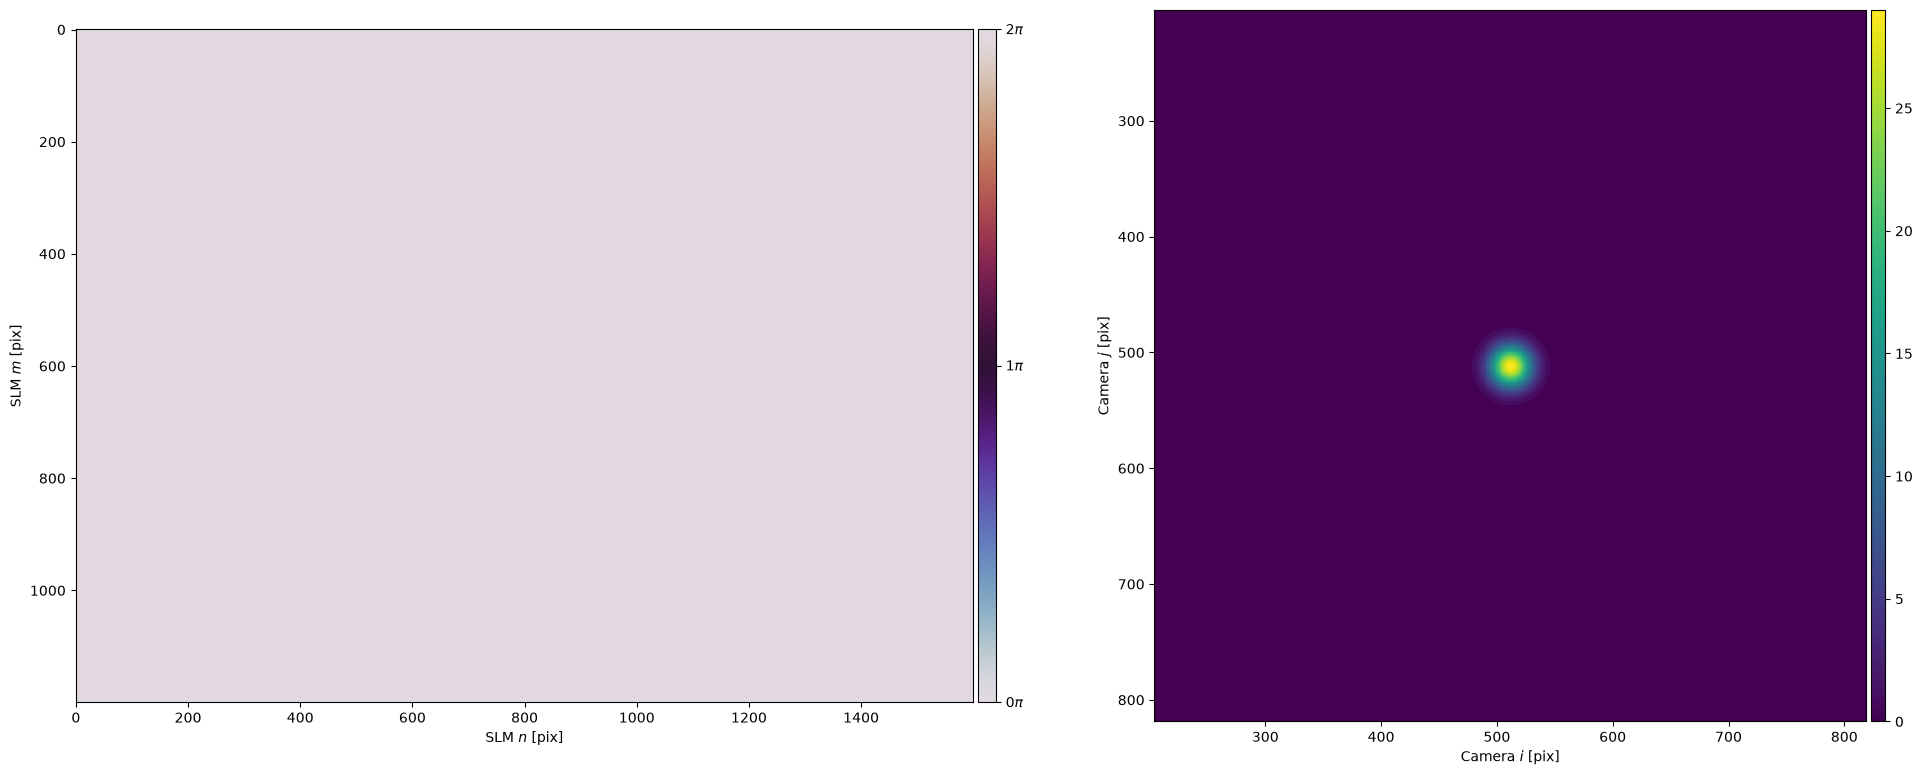

In [4]:
# make an empty array to plot onto phase
phase = np.zeros((1200, 1600))
fs.plot(phase=phase, cam_limits=0.6)

In [5]:
if "phase" in slm.source: del slm.source["phase"]
if "wavefront_superpixel" in fs.calibrations: del fs.calibrations["wavefront_superpixel"]
if "wavefront_zernike" in fs.calibrations: del fs.calibrations["wavefront_zernike"]

In [6]:
def phase_array(slm, n, center, span):
    """
    Generate an NxN array of spots using blazed gratings.

    center: (kx, ky) center of the array
    span:   +/- range around center in (kx, ky)
    """

    x0, y0 = center
    dx, dy = span

    xs = np.linspace(x0 - dx, x0 + dx, n)
    ys = np.linspace(y0 - dy, y0 + dy, n)

    # Complex-field superposition of the desired blazes
    field = np.zeros(slm.shape, dtype=complex)

    for ky in ys:
        for kx in xs:
            phase = toolbox.phase.blaze(
                grid=slm,
                vector=(kx, ky)
            )
            field += np.exp(1j * phase)

    # Convert complex field to a phase-only hologram
    return np.angle(field) % (2 * np.pi)

In [7]:
# Example
n = 10
phase = phase_array(
    slm,
    n=n,
    center=(0.00, 0.00),
    span=(0.04, 0.04)
)

In [8]:
cam.set_exposure(1e+2)

100.0

(<Axes: xlabel='SLM $n$ [pix]', ylabel='SLM $m$ [pix]'>,
 <Axes: xlabel='Camera $i$ [pix]', ylabel='Camera $j$ [pix]'>)

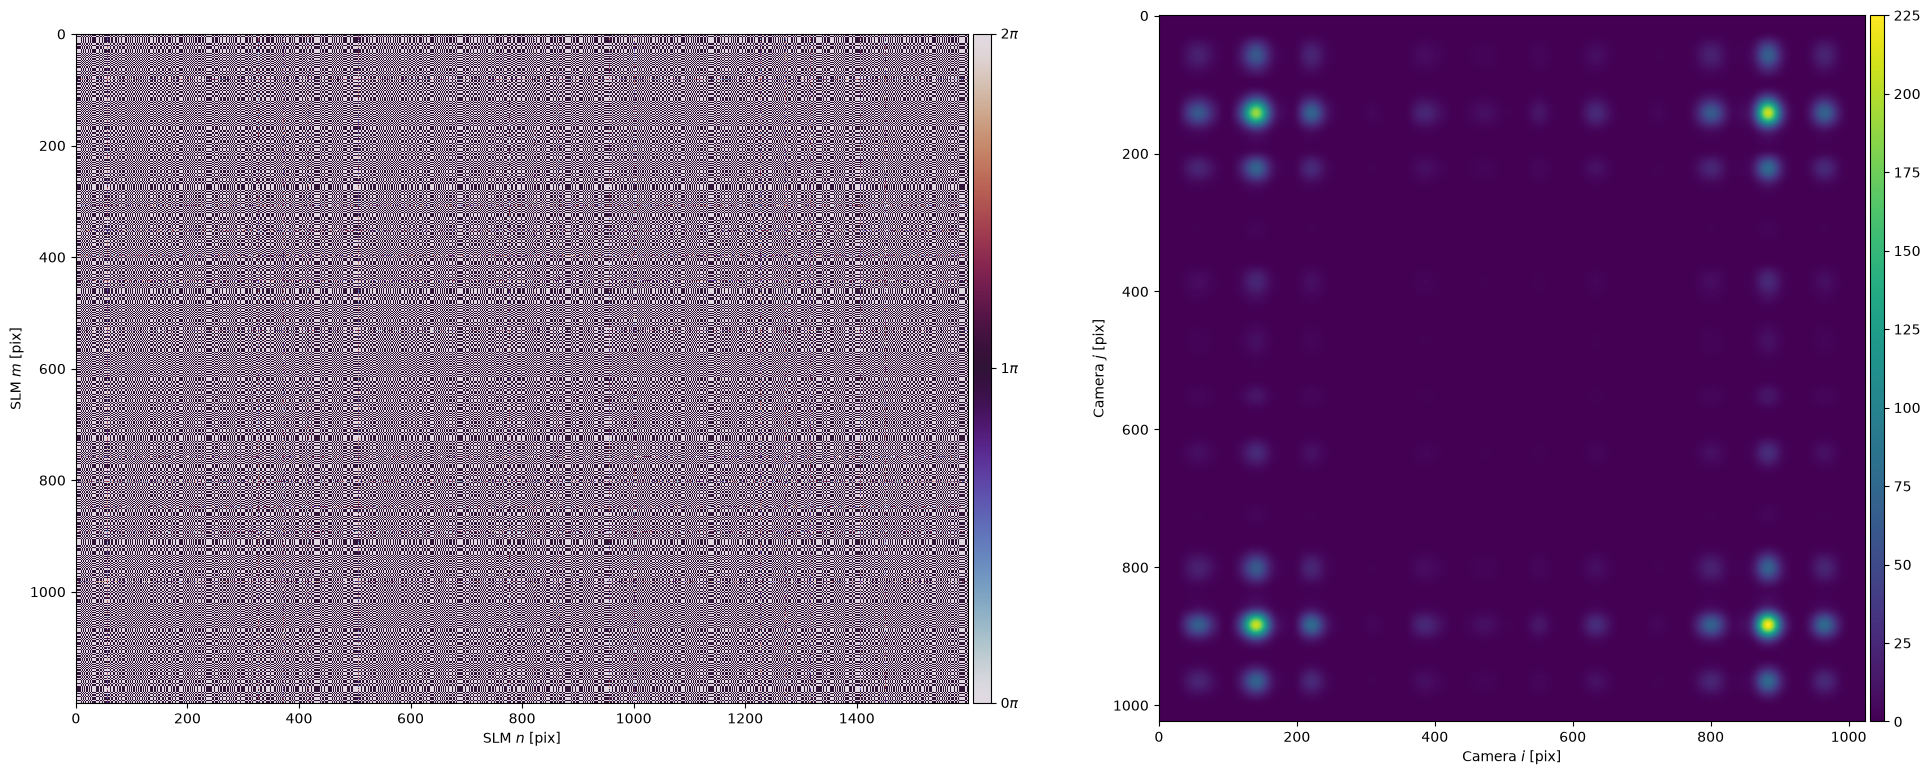

In [9]:
fs.plot(phase)

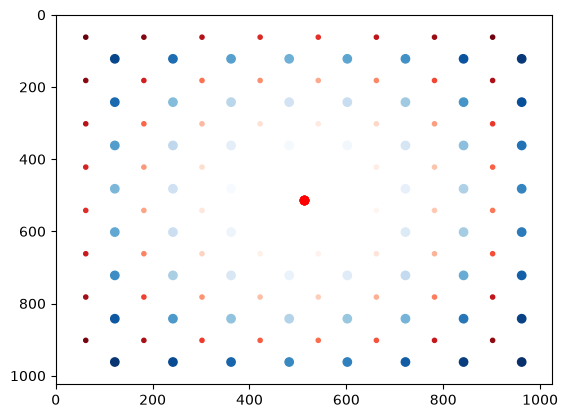

In [10]:
points_ij = fs.wavefront_calibration_points(pitch=128, plot=True)

In [11]:
from slmsuite.holography.toolbox import convert_vector

points_zernike = convert_vector(
    points_ij,
    from_units="ij",
    to_units="zernike",
    hardware=fs
)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:766: RuntimeWarning: divide by zero encountered in scalar divide
  self.target *= 1 / Hologram._norm(self.target)


optimize_weights:   0%|          | 0/10 [00:00<?, ?it/s]

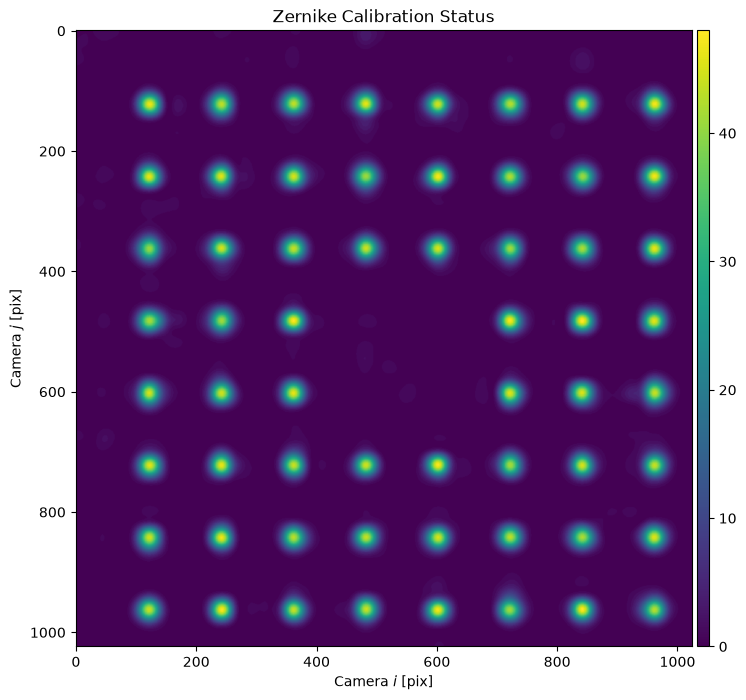

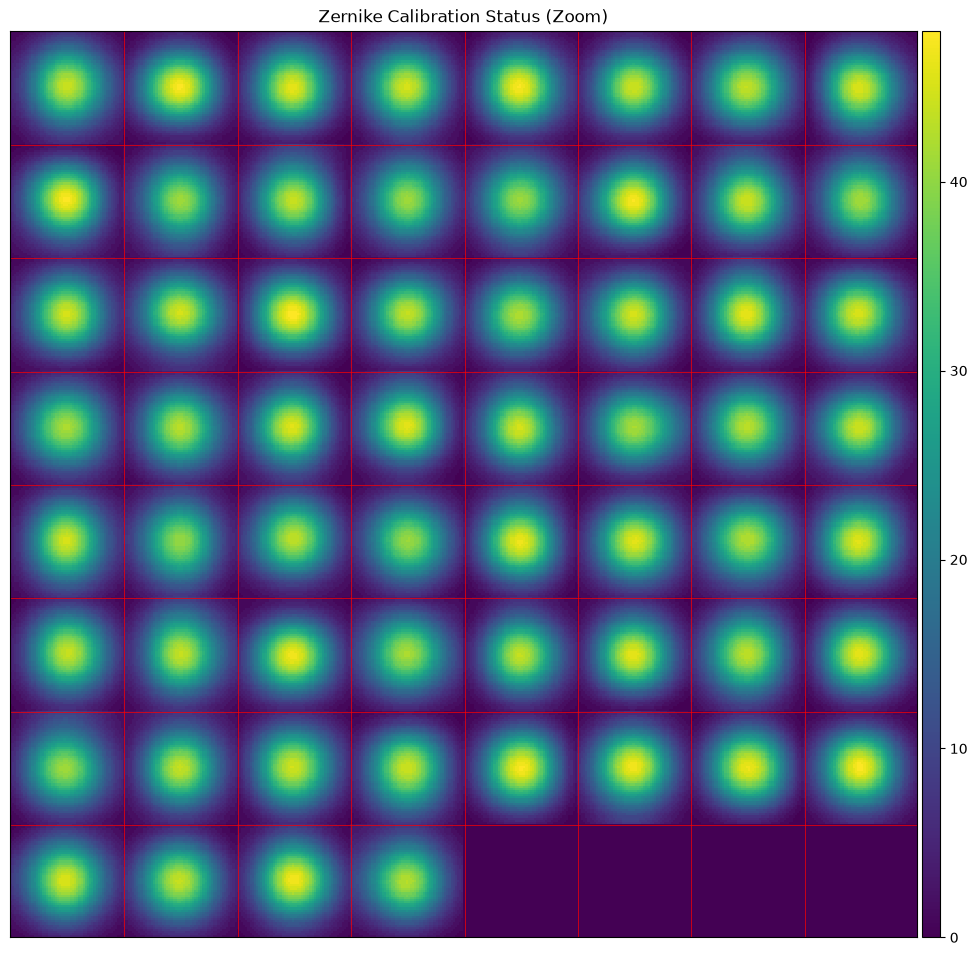

In [12]:
fs.wavefront_calibrate_zernike(
    points_zernike,
    zernike_indices=[1, 2, 4],
    perturbation=0,
    plot=2
)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:766: RuntimeWarning: divide by zero encountered in scalar divide
  self.target *= 1 / Hologram._norm(self.target)


optimize_weights:   0%|          | 0/10 [00:00<?, ?it/s]

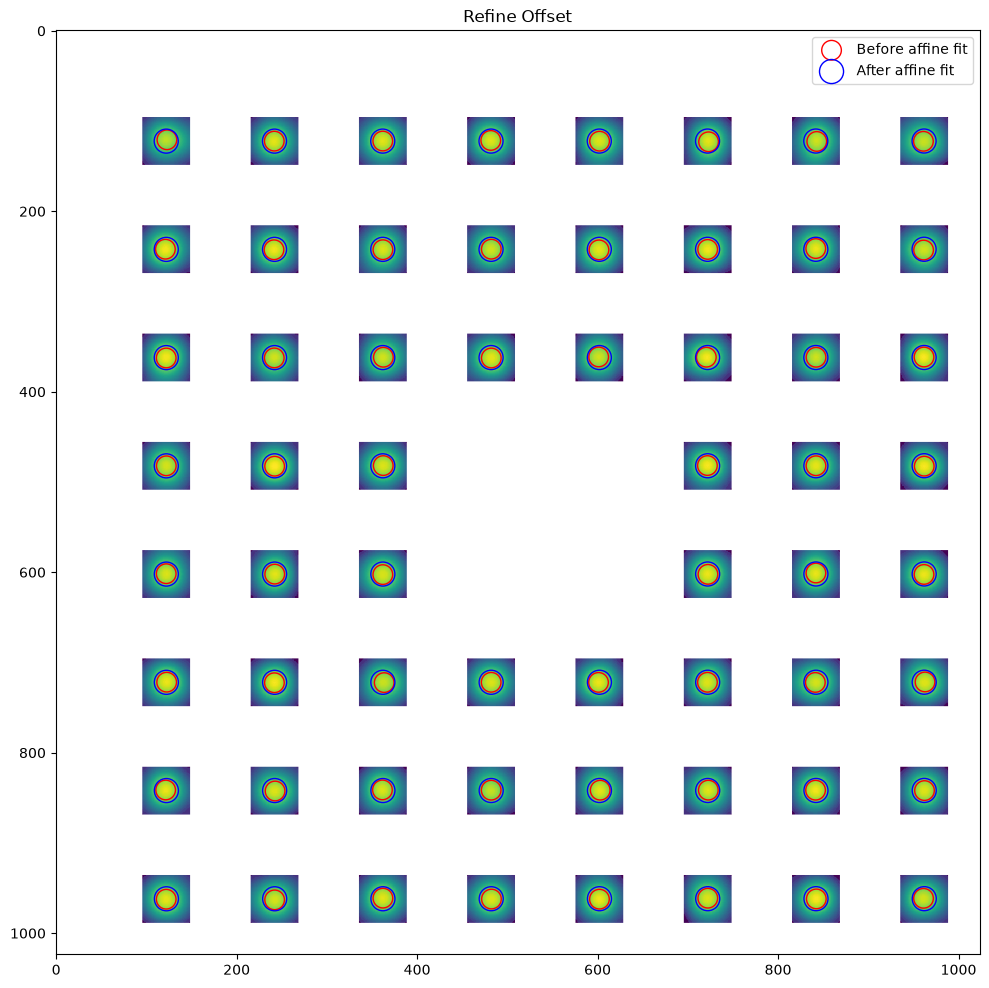

Z_4:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
fs.wavefront_calibrate_zernike(
    points_zernike,
    zernike_indices=[1, 2, 4],
    perturbation=np.linspace(
        0.5*np.pi,
        1.5*np.pi,
         5
    ),
    global_correction=True,
    plot=2
)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:766: RuntimeWarning: divide by zero encountered in scalar divide
  self.target *= 1 / Hologram._norm(self.target)


optimize_weights:   0%|          | 0/10 [00:00<?, ?it/s]

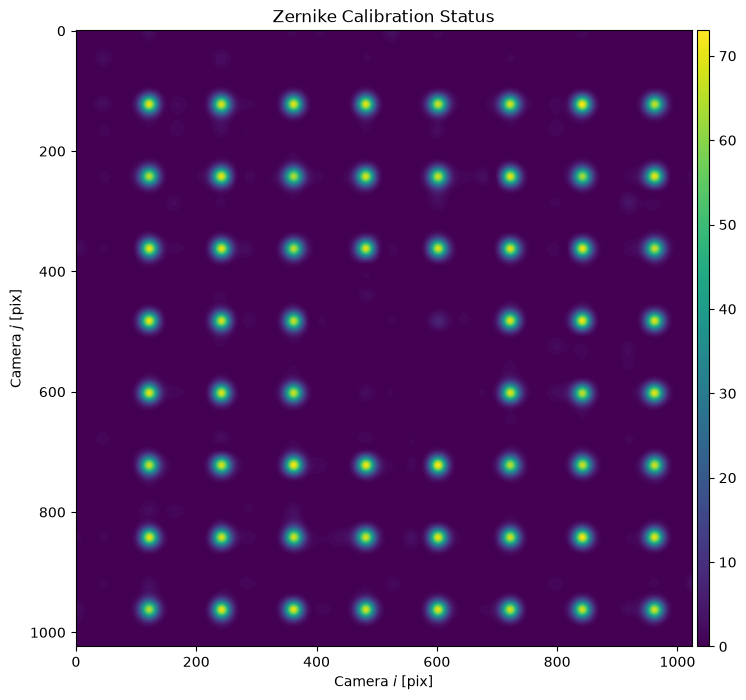

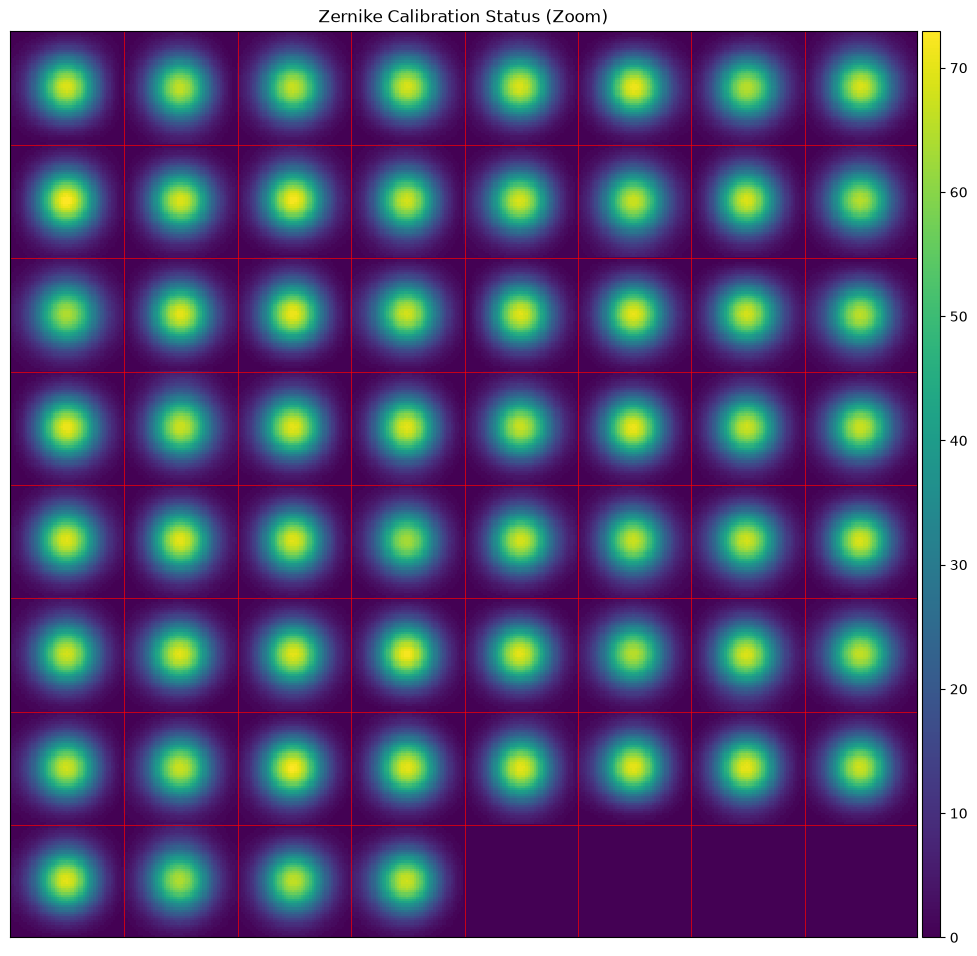

In [ ]:
fs.wavefront_calibrate_zernike(
    points_zernike,
    zernike_indices=[1, 2, 4],
    perturbation=0,
    plot=2
)

In [ ]:
# Example: Z4 coefficient = 1 rad
z4 = 45*np.pi

xyz_mm = convert_vector(
    (0, 0, z4),
    from_units="zernike",
    to_units="mm",
    hardware=fs,
)
xyz_mm

array([[2.048     ],
       [2.048     ],
       [5.34765625]])